# Sentiment Analysis — IMDB Movie Reviews

Classifies movie reviews as positive or negative using NLP and machine 
learning, achieving 90% accuracy and 0.960 ROC-AUC.

**Approach:** Text cleaning (HTML/punctuation removal, lowercasing) → 
TF-IDF vectorization with unigrams and bigrams (15,000 features) → model 
comparison (Logistic Regression vs Naive Bayes) → evaluation via accuracy, 
F1, ROC-AUC, confusion matrix → interpretability analysis via top 
sentiment-driving words.

**Result:** Logistic Regression achieved 90% accuracy with balanced 
precision/recall (0.89-0.90) across both classes — no bias toward either 
sentiment. ROC-AUC of 0.960 indicates strong class separation.

# Imports & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Text Cleaning & Label Encoding

In [3]:
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)  # remove HTML line breaks
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()  # collapse extra whitespace
    return text

df['cleaned_review'] = df['review'].apply(clean_text)
df['sentiment_label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(df[['review', 'cleaned_review', 'sentiment_label']].head(2))
print(f"\nSentiment distribution:\n{df['sentiment_label'].value_counts()}")

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   

                                      cleaned_review  sentiment_label  
0  one of the other reviewers has mentioned that ...                1  
1  a wonderful little production the filming tech...                1  

Sentiment distribution:
sentiment_label
1    25000
0    25000
Name: count, dtype: int64


# TF-IDF Vectorization & Train/Test Split

In [6]:
tfidf = TfidfVectorizer(max_features=15000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape: {X_test_tfidf.shape}")

Train shape: (40000, 15000)
Test shape: (10000, 15000)


# Model Training (Logistic Regression vs Naive Bayes

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=10, random_state=42),
    'Naive Bayes': MultinomialNB()
}
results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    proba = model.predict_proba(X_test_tfidf)[:, 1]
    
    results[name] = {
        'model': model,
        'preds': preds,
        'proba': proba,
        'accuracy': accuracy_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, proba)
    }
    
    print(f"\n{name}")
    print(f"  Accuracy: {results[name]['accuracy']:.3f}")
    print(f"  F1-Score: {results[name]['f1']:.3f}")
    print(f"  ROC-AUC:  {results[name]['roc_auc']:.3f}")


Logistic Regression
  Accuracy: 0.895
  F1-Score: 0.896
  ROC-AUC:  0.960

Naive Bayes
  Accuracy: 0.868
  F1-Score: 0.870
  ROC-AUC:  0.939


# Model Evaluation — Confusion Matrix & ROC Curve

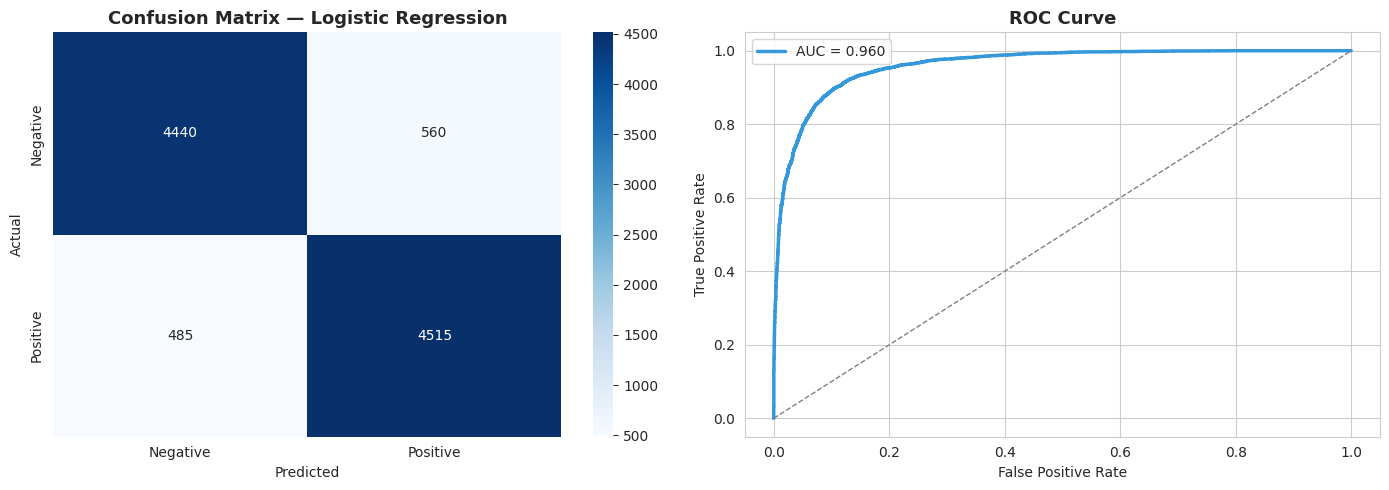

Best model: Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [9]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_result = results[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best_result['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, best_result['proba'])
axes[1].plot(fpr, tpr, color='#3498db', lw=2.5, label=f"AUC = {best_result['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('sentiment_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best model: {best_model_name}")
print(classification_report(y_test, best_result['preds']))

# Interpretability — Top Sentiment-Driving Words

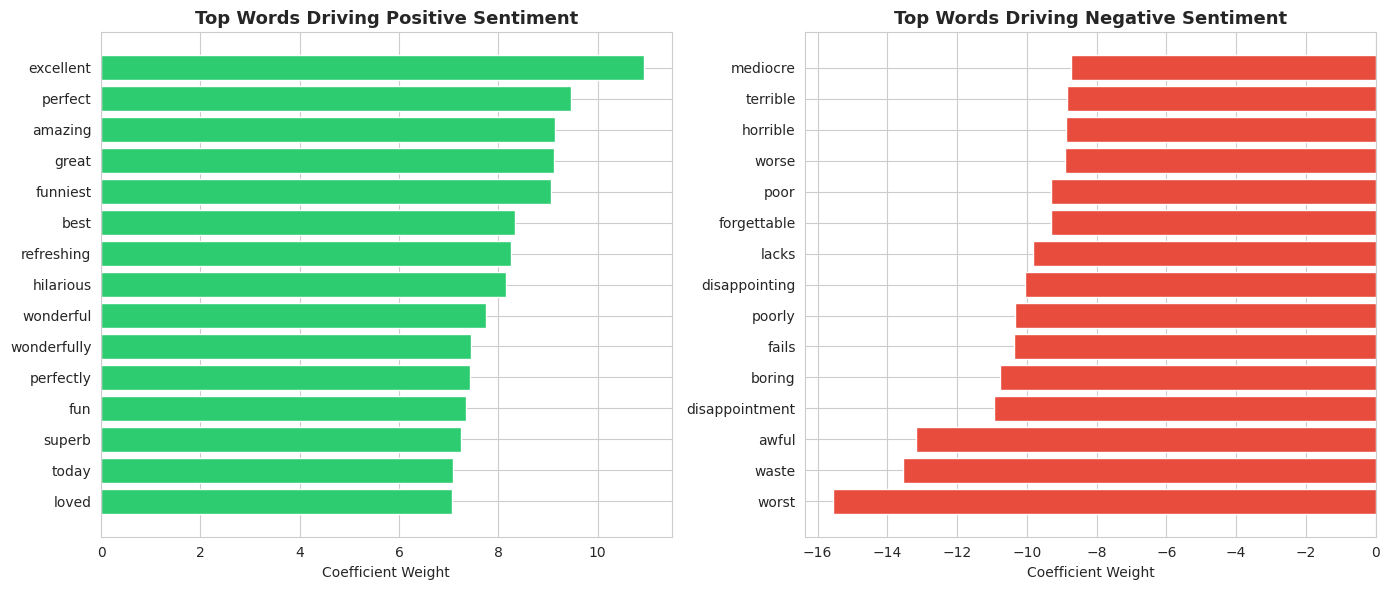

In [10]:
if best_model_name == 'Logistic Regression':
    feature_names = np.array(tfidf.get_feature_names_out())
    coefs = best_result['model'].coef_[0]
    
    top_positive_idx = np.argsort(coefs)[-15:]
    top_negative_idx = np.argsort(coefs)[:15]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].barh(feature_names[top_positive_idx], coefs[top_positive_idx], color='#2ecc71')
    axes[0].set_title('Top Words Driving Positive Sentiment', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Coefficient Weight')
    
    axes[1].barh(feature_names[top_negative_idx], coefs[top_negative_idx], color='#e74c3c')
    axes[1].set_title('Top Words Driving Negative Sentiment', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Coefficient Weight')
    
    plt.tight_layout()
    plt.savefig('sentiment_top_words.png', dpi=150, bbox_inches='tight')
    plt.show()